# Machine learning Mental Health Dectection Model
## Goals : To create the model that predicts the Mental health score of the students



# 1. Importing libraries

In [1]:
#basics imports
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns

#preprocessing imports
from scipy.stats import iqr
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from category_encoders import TargetEncoder
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer, StandardScaler, OrdinalEncoder, OneHotEncoder

#Model 
from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV

#Metrices imports
from sklearn.metrics import accuracy_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

#Reproducibility 
SEED = 42
import warnings
warnings.filterwarnings("ignore") 
pd.set_option('display.max_columns', None)
print('All Import successfull.....')

All Import successfull.....


# 2. Loading and validating data

In [2]:
df = pd.read_csv("data/datasets.csv")
print(f"Data set with rows -> {df.shape[0]} and columns -> {df.shape[1]}")
print("Data set loaded successfully...........")


Data set with rows -> 5000 and columns -> 13
Data set loaded successfully...........


# 3. Data Understanding

In [3]:
quality = {
    "dtypes" : df.dtypes,
    "null count" : df.isnull().sum(), 
    "nuniques" : df.nunique()
    
}

quality = pd.DataFrame(quality) 
display(quality)


,dtypes,null count,nuniques
Age,int64,0,7
Gender,str,0,2
Country,str,0,111
Academic_Level,str,0,3
Most_Used_Platform,str,0,12
Purpose_Of_Use,str,0,4
Avg_Daily_Usage_Hours,float64,0,79
Daily_Unlocks,int64,0,200
Study_Hours,float64,0,76
Physical_Activity_Hours,float64,0,44


In [4]:
# There is no any null values data is clean and 2 duplicate rows are deleted

In [5]:
df.describe()

,Age,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Mental_Health_Score
count,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,20.82180,5.078460,171.452600,3.008420,1.751000,6.634580,6.230980
std,1.73662,1.653913,42.858254,1.637018,0.668398,1.221391,1.278701
min,18.00000,1.000000,62.000000,0.300000,-0.400000,3.600000,3.600000
25%,19.00000,3.800000,140.000000,1.500000,1.300000,5.600000,5.100000
50%,21.00000,5.000000,171.000000,2.800000,1.700000,6.600000,6.100000
75%,22.00000,6.300000,204.000000,4.200000,2.200000,7.500000,7.100000
max,24.00000,8.800000,273.000000,8.300000,4.100000,9.900000,9.400000


In [6]:
#From this description Physical_Activity_Hours has unrealistic negative value

# 4. Exploratory Data Analysis

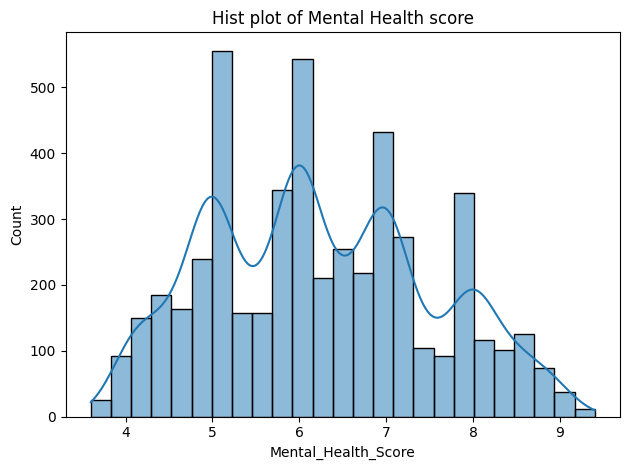

In [7]:
#lets understand the distribution of the target columns
sns.histplot(data = df, x='Mental_Health_Score', kde = True)
plt.title("Hist plot of Mental Health score")
plt.tight_layout()
plt.show()



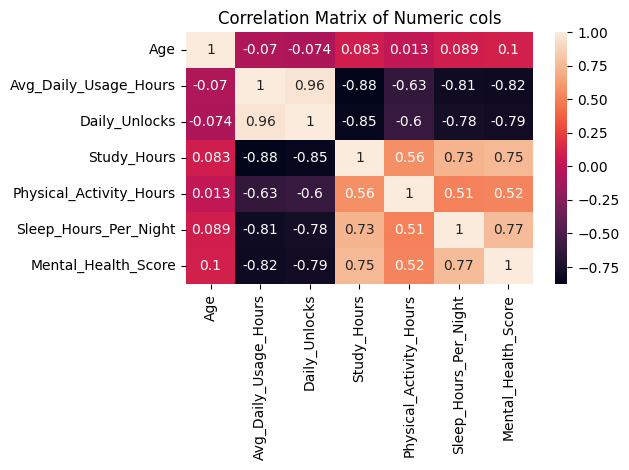

In [8]:
sns.heatmap(df.corr(numeric_only = True), annot = True)
plt.title("Correlation Matrix of Numeric cols")
plt.tight_layout()
plt.show()

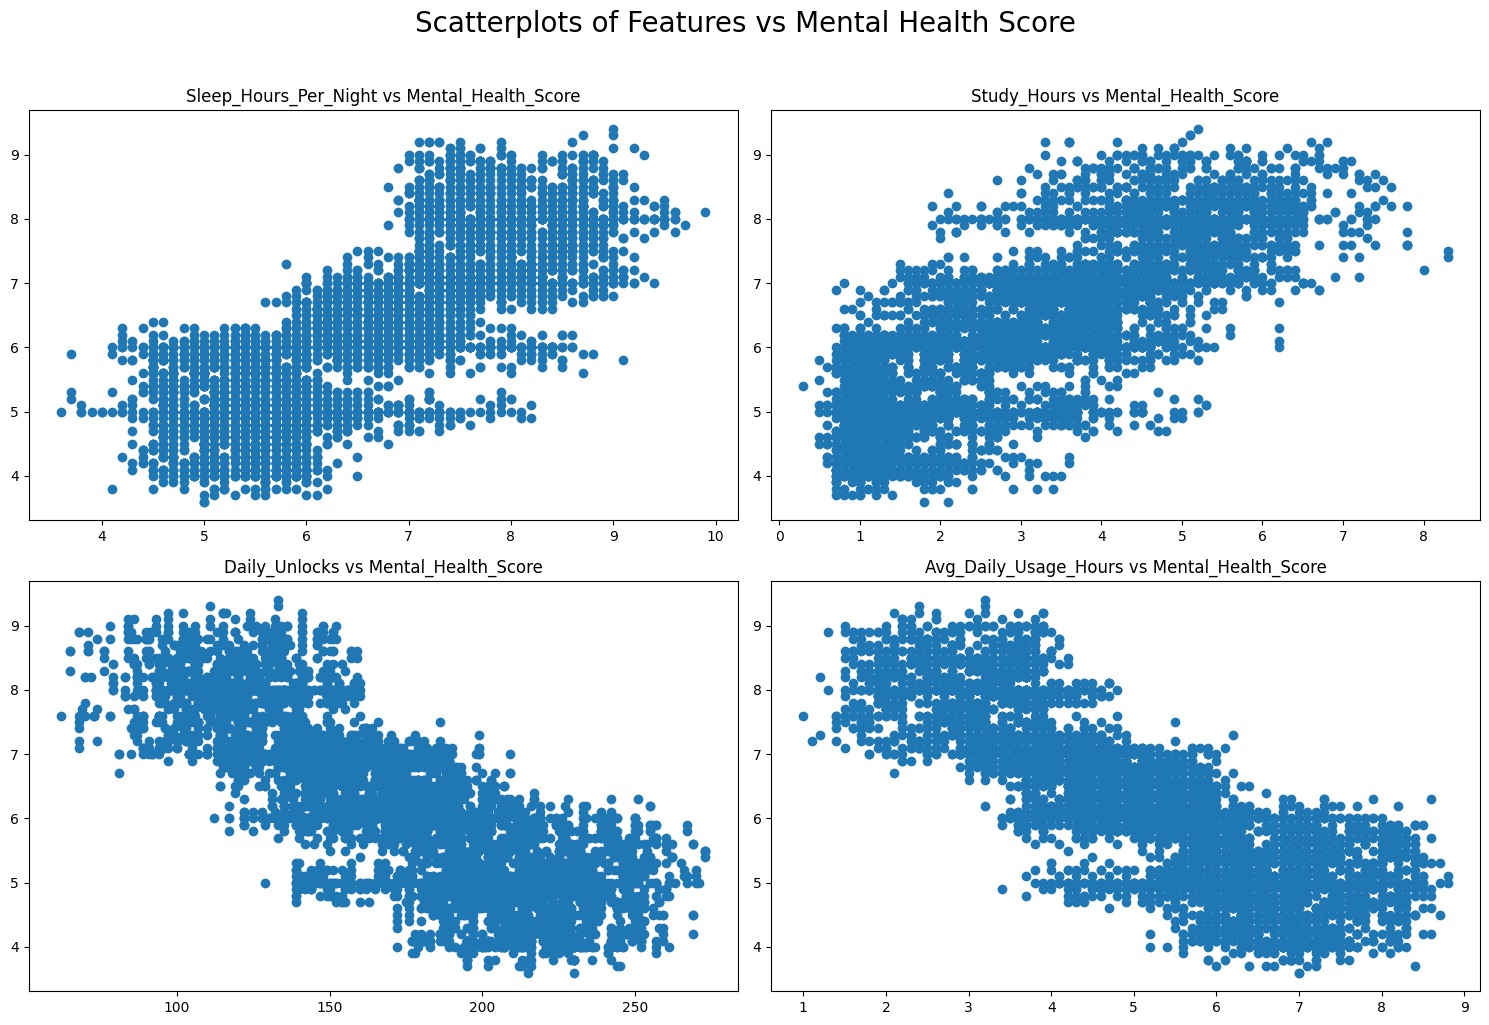

In [9]:
scatter_plot_cols = ["Sleep_Hours_Per_Night", "Study_Hours", "Daily_Unlocks", "Avg_Daily_Usage_Hours"]
target_cols = "Mental_Health_Score"
fig, axes = plt.subplots(2,2, figsize = (15,10))
axes = axes.flatten() 
for i,col in enumerate(scatter_plot_cols): 
    axes[i].scatter(df[col], df[target_cols])
    axes[i].set_title(f"{col} vs {target_cols}")

plt.suptitle("Scatterplots of Features vs Mental Health Score", fontsize=20, y=1.02)
plt.tight_layout() 
plt.show()

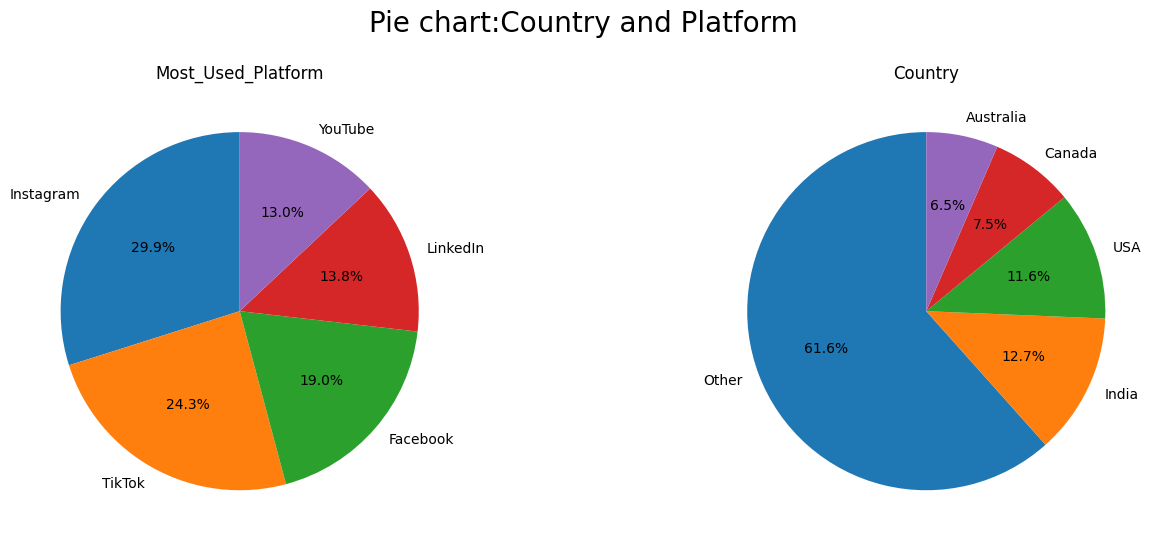

In [10]:
fig, axes = plt.subplots(1,2, figsize = (15,5))
pie_cols = ['Most_Used_Platform','Country']
for i,col in enumerate(pie_cols): 
    counts = df[col].value_counts().sort_values(ascending = False)[:5]
    axes[i].pie(counts.values, labels=counts.index, autopct="%1.1f%%", startangle=90)
    axes[i].set_title(f"{col}")
    

plt.tight_layout()
plt.suptitle("Pie chart:Country and Platform", fontsize = 20 , y = 1.08)
plt.show()

In [11]:
df.columns

Index(['Age', 'Gender', 'Country', 'Academic_Level', 'Most_Used_Platform',
       'Purpose_Of_Use', 'Avg_Daily_Usage_Hours', 'Daily_Unlocks',
       'Study_Hours', 'Physical_Activity_Hours', 'Sleep_Hours_Per_Night',
       'Stress_Level', 'Mental_Health_Score'],
      dtype='str')

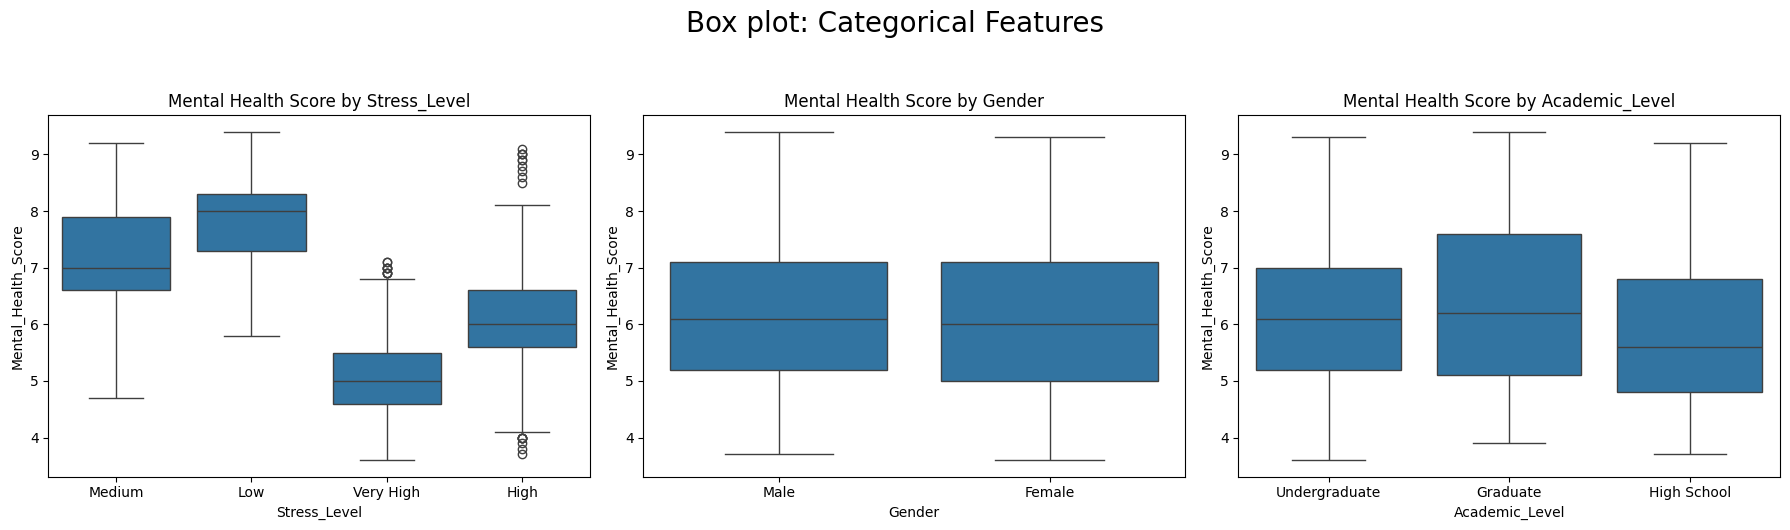

In [12]:
box_cols = ['Stress_Level','Gender','Academic_Level']
fig, axes = plt.subplots(1,3, figsize =(18,5))
for i, col in enumerate(box_cols):
    sns.boxplot(data=df, x=col, y="Mental_Health_Score", ax=axes[i])
    axes[i].set_title(f"Mental Health Score by {col}")
    

plt.suptitle("Box plot: Categorical Features", fontsize=20, y = 1.05)
plt.tight_layout()
plt.show()

# 5. Data Cleaning

In [13]:
#dropping duplicates
n_rows = len(df)
df.drop_duplicates(df, inplace = True)
print(f"Duplicate Rows-> {n_rows - len(df)} after dropping rows-> {len(df)}")


Duplicate Rows-> 2 after dropping rows-> 4998


In [14]:
# We have unrealistic value in Physical Activity Hours
df['Physical_Activity_Hours'] = df['Physical_Activity_Hours'].clip(lower=0)

# 6. Checking Skewness

In [15]:
numeric_cols = df.select_dtypes(include = 'number')
skewness = numeric_cols.skew()
display(skewness) 
#value near 0 not skewed value greater than 0 -> Right skewed and less than 0 -> left skewed
skewed_col = "Study_Hours"


Age                        0.155008
Avg_Daily_Usage_Hours      0.005575
Daily_Unlocks              0.002309
Study_Hours                0.436125
Physical_Activity_Hours    0.053288
Sleep_Hours_Per_Night      0.123919
Mental_Health_Score        0.207086
dtype: float64

In [16]:
numeric_cols = numeric_cols.columns.to_list()


# 7. Detecting and solving outliers

In [17]:
Q1 = df[numeric_cols].quantile(0.25)
Q3 = df[numeric_cols].quantile(0.75)

IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outlier_mask = (
    (df[numeric_cols] < lower_bound) |
    (df[numeric_cols] > upper_bound)
)

print("Outliers per column:")
print(outlier_mask.sum())

print("Rows containing outliers:", outlier_mask.any(axis=1).sum())

df = df[~outlier_mask.any(axis=1)]


Outliers per column:
Age                         0
Avg_Daily_Usage_Hours       0
Daily_Unlocks               0
Study_Hours                 2
Physical_Activity_Hours    12
Sleep_Hours_Per_Night       0
Mental_Health_Score         0
dtype: int64
Rows containing outliers: 14


# 8. Train test splitting

In [18]:
X = df.drop(columns=['Mental_Health_Score'])
y = df['Mental_Health_Score']

In [19]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2,random_state = 42)


In [20]:
df.head()

,Age,Gender,Country,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Stress_Level,Mental_Health_Score
0,21,Male,Other,Undergraduate,Facebook,Networking,4.0,134,4.5,2.2,6.7,Medium,6.8
1,23,Female,Other,Graduate,LinkedIn,Education,1.6,73,7.0,2.4,8.6,Low,7.6
2,22,Male,Canada,Undergraduate,Instagram,Entertainment,4.6,166,4.0,1.8,6.7,Medium,7.0
3,18,Male,Other,High School,Snapchat,Entertainment,7.0,220,1.0,1.7,5.4,Very High,5.3
4,24,Female,Other,Graduate,Facebook,Networking,7.5,237,1.0,1.1,5.0,Very High,4.4


# 9. Encoding Pipeline

In [21]:
skewed_col = ["Study_Hours"] #-> remove skewness and perform scaler
one_hot_cols=['Gender', 'Academic_Level','Most_Used_Platform','Purpose_Of_Use']
numeric_cols = ['Age', 'Avg_Daily_Usage_Hours','Daily_Unlocks','Physical_Activity_Hours','Sleep_Hours_Per_Night']
ordinal_cols =['Stress_Level']
country_cols = ['Country']




In [22]:
# Skewed numerical columns
skew_pipeline = Pipeline(steps=[
    ("Log_transform", FunctionTransformer(np.log1p,feature_names_out="one-to-one")),
    ("Standard_scaler", StandardScaler())
])


# Normal numerical columns
numeric_pipeline = Pipeline(steps=[
    ("Standard_scaler", StandardScaler())
])


# Ordinal categorical columns
ordinal_pipeline = Pipeline(steps=[
    ("encode", OrdinalEncoder(
        categories=[['Low', 'Medium', 'High', 'Very High']]
    )),
    ("Standard_scaler", StandardScaler())
])


# One-hot categorical columns
categorical_pipeline = Pipeline(steps=[
    ("One_hot_encoding", OneHotEncoder(
        drop="first",
        handle_unknown="ignore"
    ))
])


# Country target encoding
country_pipeline = Pipeline(steps=[
    ("country_encode", TargetEncoder()),
    ("Standard_scaler", StandardScaler())
])


# Preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ("Skew_pipeline", skew_pipeline, skewed_col),
        ("numeric_pipeline", numeric_pipeline, numeric_cols),
        ("ordinal_pipeline", ordinal_pipeline, ordinal_cols),
        ("categorical_pipeline", categorical_pipeline, one_hot_cols),
        ("country_pipeline", country_pipeline, country_cols)
    ]
)

# 10. Model Zoo


In [23]:
cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=SEED
)

models = {
    "Linear_Regression": Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("linear_Regression", LinearRegression())
    ]),

    "Random_Forest": Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("Random_forest", RandomForestRegressor(
            random_state=SEED
        ))
    ]),

    "XG_boost": Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("XG_regressor", XGBRegressor(
            n_estimators=300,
            max_depth=6,
            learning_rate=0.1,
            random_state=SEED,
            n_jobs=-1
        ))
    ])
}

results = {}

for name, pipeline in models.items():

    scores = cross_val_score(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring="r2"
    )

    results[name] = {
        "mean_score": scores.mean(),
        "std_score": scores.std()
    }

    print(
        f"{name} -> "
        f"{scores.mean():.4f} ± {scores.std():.4f}"
    )

best_name = max(
    results,
    key=lambda k: results[k]["mean_score"]
)

print("Best model:", best_name)

Linear_Regression -> 0.7387 ± 0.0137
Random_Forest -> 0.8975 ± 0.0052
XG_boost -> 0.8972 ± 0.0060
Best model: Random_Forest


In [24]:
best_pipe = models[best_name]
best_pipe.fit(X_train, y_train)
y_pred = best_pipe.predict(X_test)

In [25]:
r2 = r2_score(y_test, y_pred)

# 11. Hyperparameter Tuning for XgRegressor

In [26]:
param_grid={
     "XG_regressor__n_estimators":[300,100,200],
     "XG_regressor__max_depth":[6,5,10],
     "XG_regressor__learning_rate":[0.1,0.01,0.001]
}
pipeline = models['XG_boost']
grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=cv,
    scoring="r2",
    n_jobs=-1
)

grid.fit(X_train, y_train)

print(grid.best_params_)
print(grid.best_score_)

{'XG_regressor__learning_rate': 0.1, 'XG_regressor__max_depth': 10, 'XG_regressor__n_estimators': 300}
0.903539622424501


In [27]:
grid.best_estimator_

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('XG_regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('Skew_pipeline', ...), ('numeric_pipeline', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the outp

In [28]:
model_pipeline = grid.best_estimator_
model_pipeline.fit(X_train, y_train)
y_test_pred = model_pipeline.predict(X_test)
y_train_pred = model_pipeline.predict(X_train)



In [29]:
print("Train R²:", r2_score(y_train, y_train_pred))
print("Test R² :", r2_score(y_test, y_test_pred))

print("Train MAE:", mean_absolute_error(y_train, y_train_pred))
print("Test MAE :", mean_absolute_error(y_test, y_test_pred))

print("Train RMSE:", np.sqrt(mean_squared_error(y_train, y_train_pred)))
print("Test RMSE :", np.sqrt(mean_squared_error(y_test, y_test_pred)))

Train R²: 0.999760800403449
Test R² : 0.913453930138574
Train MAE: 0.012655389198301299
Test MAE : 0.26998946492148257
Train RMSE: 0.01977163267928797
Test RMSE : 0.3747814886041672


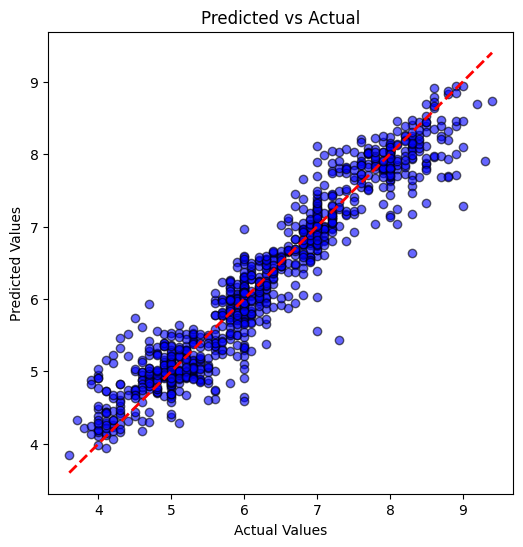

In [30]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_test_pred, alpha=0.6, color="blue", edgecolor="k")
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         "r--", lw=2)  
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Predicted vs Actual")
plt.show()

# 12. Feature Importances

In [33]:
model = model_pipeline.named_steps['XG_regressor']
model

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes

In [35]:
preprocessor = model_pipeline.named_steps['preprocessor']
preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('Skew_pipeline', ...), ('numeric_pipeline', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` 

In [38]:
importance = model.feature_importances_
features_name = preprocessor.get_feature_names_out()

<BarContainer object of 25 artists>

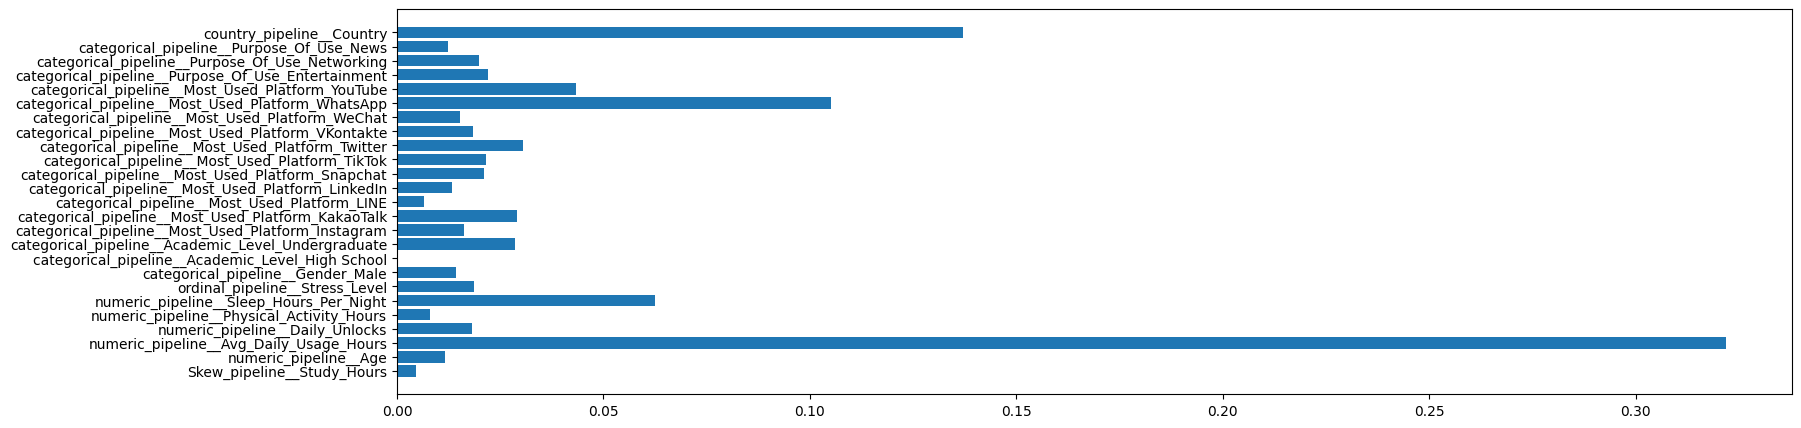

In [45]:
plt.figure(figsize =(18,5))
plt.barh(features_name, importance)

In [46]:
# Avg Daily usage hours is given more importance by the model

# 13.Explainable Ai using lime 

In [47]:
preprocessor = model_pipeline.named_steps["preprocessor"]
xgb_model = model_pipeline.named_steps["XG_regressor"]


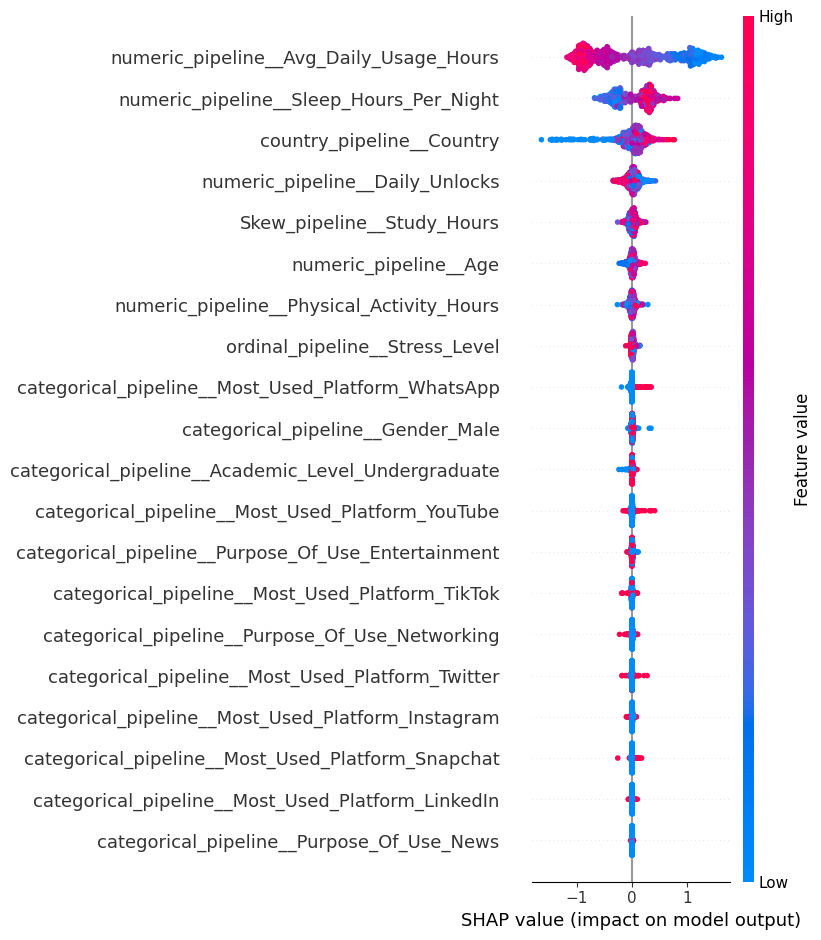

In [51]:
X_train_transformed = preprocessor.transform(X_train)
X_test_transformed = preprocessor.transform(X_test)
feature_names = preprocessor.get_feature_names_out()
import shap

explainer = shap.TreeExplainer(xgb_model)

shap_values = explainer.shap_values(X_test_transformed)
shap.summary_plot(
    shap_values,
    X_test_transformed,
    feature_names=feature_names
)

In [52]:
shap_values

array([[ 7.3079742e-03,  3.1070891e-03,  7.5954771e-01, ...,
        -3.4262871e-03, -1.8711095e-05, -1.0575335e+00],
       [-3.9400950e-02, -4.7900472e-02, -1.0861572e+00, ...,
        -2.0368933e-03,  7.9135997e-03,  3.8910478e-02],
       [-3.4466408e-02,  1.1129492e-02, -8.7523949e-01, ...,
        -2.3410479e-03,  4.7252214e-04,  4.6748765e-02],
       ...,
       [-5.5037141e-02,  2.7257591e-02, -1.0080854e+00, ...,
         3.3604950e-04,  9.3674371e-03, -1.2525380e-01],
       [ 1.5156809e-02,  3.2374017e-02, -7.7042896e-01, ...,
        -1.0954639e-02, -9.0537209e-04,  6.9088139e-02],
       [-2.2000792e-02,  1.8057421e-02, -9.4692641e-01, ...,
        -2.0216513e-02, -8.9558342e-04, -3.4776032e-01]],
      shape=(997, 25), dtype=float32)

In [60]:
explainer = shap.Explainer(model, X_train_transformed)
shap_values = explainer(X_test_transformed)
shap_values.values

 99%|===================| 987/997 [00:38<00:00]        

array([[ 1.34168207e-02,  4.81046414e-03,  4.96078572e-01, ...,
        -9.56197505e-05,  2.72544924e-04, -9.02192455e-01],
       [-1.25916216e-01, -4.77717054e-02, -8.87888613e-01, ...,
         1.53682895e-03,  1.03608911e-02,  2.46087185e-03],
       [-6.62971791e-02,  1.58487049e-02, -8.27189008e-01, ...,
         1.36095281e-03,  7.32589789e-04,  2.26628079e-02],
       ...,
       [-1.00252576e-01,  2.37893439e-02, -7.92700720e-01, ...,
         2.94333655e-03,  1.00520585e-02, -2.33245151e-01],
       [-2.47964088e-03,  3.12657133e-02, -6.90156854e-01, ...,
        -3.72980896e-03, -3.41472602e-04,  5.28163995e-02],
       [-5.73848577e-02,  1.53525118e-02, -6.56620290e-01, ...,
        -3.34044196e-02, -3.15676712e-04, -4.83104230e-01]],
      shape=(997, 25))

In [62]:
shap_values.feature_names = feature_names

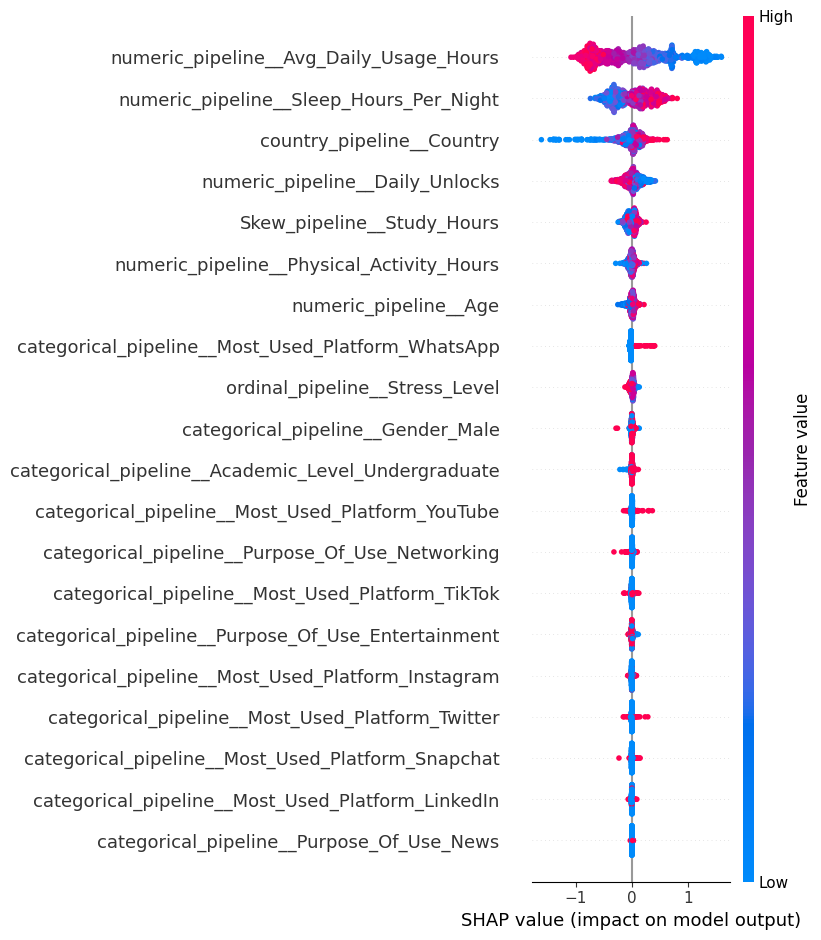

In [58]:
shap.summary_plot(
    shap_values.values,
    X_test_transformed,
    feature_names=feature_names
)

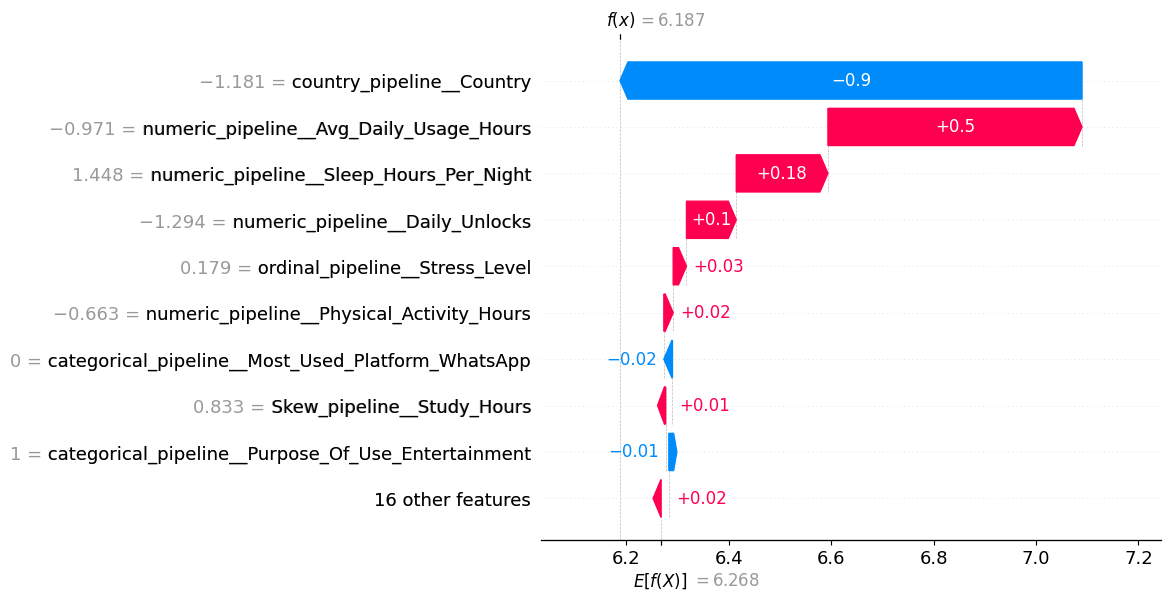

In [63]:
shap.plots.waterfall(shap_values[0])

# 14.Saving the model


In [64]:
import joblib
joblib.dump(model_pipeline, "Mental_Health.pkl")

['Mental_Health.pkl']

In [66]:
df.columns

TypeError: 'Index' object is not callable

In [73]:
columns = df['Country'].value_counts().index.tolist()

print(columns)

['Other', 'India', 'USA', 'Canada', 'Australia', 'UK', 'Germany', 'Mexico', 'Turkey', 'France', 'Spain', 'Ireland', 'Denmark', 'Japan', 'Switzerland', 'Nepal', 'Italy', 'Russia', 'Sri Lanka', 'Maldives', 'Bangladesh', 'Pakistan', 'Poland', 'South Korea', 'China', 'Brazil', 'Singapore', 'New Zealand', 'Malaysia', 'Netherlands', 'UAE', 'Finland', 'Uzbekistan', 'Qatar', 'Sweden', 'Norway', 'Egypt', 'Paraguay', 'Cyprus', 'Vietnam', 'Argentina', 'Costa Rica', 'Romania', 'Moldova', 'Georgia', 'Andorra', 'Belgium', 'Greece', 'South Africa', 'Peru', 'Panama', 'Trinidad', 'Czech Republic', 'Latvia', 'Lithuania', 'North Macedonia', 'Lebanon', 'Iraq', 'Afghanistan', 'Hong Kong', 'Morocco', 'Nigeria', 'Slovakia', 'Ukraine', 'Kazakhstan', 'Tajikistan', 'Monaco', 'San Marino', 'Vatican City', 'Albania', 'Austria', 'Portugal', 'Philippines', 'Indonesia', 'Taiwan', 'Israel', 'Ghana', 'Chile', 'Venezuela', 'Jamaica', 'Bahamas', 'Hungary', 'Bulgaria', 'Estonia', 'Azerbaijan', 'Malta', 'Luxembourg', 'Lie

In [80]:
df['Stress_Level'].value_counts().index.to_list()

['Very High', 'High', 'Medium', 'Low']